# INTRODUCTION


<span style="font-family: 'Arial'; font-size:16px; color:white;text-align:left;">

#### This project focuses on data analysis using the Pandas library in Python. The main objective is to explore, clean, and analyze the dataset to uncover useful insights and trends. Pandas provides powerful tools for data manipulation, making it easier to handle large datasets efficiently.

#### In this project, various operations such as data cleaning, grouping, aggregation, visualization, and statistical analysis have been performed. The aim is to draw meaningful conclusions from raw data and present them in a structured and understandable way.

#### By the end of this analysis, the project demonstrates how data can be transformed into actionable insights using Pandas, showcasing essential data-handling skills for real-world applications.
</span>

In [3]:
# IMPORTING LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
#IMPORTING DATASET
df=pd.read_csv(r'supermarket_sales.csv')

       Invoice ID Branch       City Customer type  Gender            Product line  Unit price  Quantity  Tax 5%   Total        Date   Time      Payment    COGS  Gross margin percentage  Gross income  Rating  Customer Age  Discount  Membership duration  Loyalty points   Feedback        Product
0     754-24-1409      A   Mandalay        Normal  Female       Health and beauty       68.33         6   31.36   92.04  2021-02-02  18:49         Cash  772.95                     4.76         12.00     7.5           NaN     26.30                  NaN              96       Good         Lotion
1     859-45-5012      C     Yangon        Normal  Female       Health and beauty       63.33        10   22.60  138.21  2021-01-04  20:43      Ewallet  280.50                     4.76         40.87     9.6           NaN      0.00                  NaN              64       good         Lotion
2     328-27-2679      B  Naypyitaw        Normal  FEMALE      Home and lifestyle       91.94         4   31.61  220.8

In [5]:
#Identify the number of rows and columns in the dataset
df.shape

(1020, 23)

In [6]:
#to identify the datatype of each column
df.dtypes

Invoice ID                  object
Branch                      object
City                        object
Customer type               object
Gender                      object
Product line                object
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Total                      float64
Date                        object
Time                        object
Payment                     object
COGS                       float64
Gross margin percentage    float64
Gross income               float64
Rating                     float64
Customer Age               float64
Discount                   float64
Membership duration        float64
Loyalty points               int64
Feedback                    object
Product                     object
dtype: object

In [7]:
def sec(var):
    return(var+':00')

df['Time']=df['Time'].apply(sec)

In [8]:
df['Time']=pd.to_datetime(df['Time'])

C:\Users\abhij\AppData\Local\Temp\ipykernel_22060\3907310423.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time']=pd.to_datetime(df['Time'])


In [9]:
#convert date to datetime
df['Date'] = pd.to_datetime(df['Date'])

df.dtypes

Invoice ID                         object
Branch                             object
City                               object
Customer type                      object
Gender                             object
Product line                       object
Unit price                        float64
Quantity                            int64
Tax 5%                            float64
Total                             float64
Date                       datetime64[ns]
Time                       datetime64[ns]
Payment                            object
COGS                              float64
Gross margin percentage           float64
Gross income                      float64
Rating                            float64
Customer Age                      float64
Discount                          float64
Membership duration               float64
Loyalty points                      int64
Feedback                           object
Product                            object
dtype: object

In [10]:
#To check for any null values
df.isnull().sum()

Invoice ID                   0
Branch                       0
City                         0
Customer type                0
Gender                       0
Product line                 0
Unit price                   0
Quantity                     0
Tax 5%                      51
Total                       32
Date                         0
Time                         0
Payment                      0
COGS                         0
Gross margin percentage      0
Gross income                 0
Rating                     100
Customer Age               514
Discount                     0
Membership duration        491
Loyalty points               0
Feedback                     0
Product                      0
dtype: int64

In [11]:
#Filing missing values in tax with mean values
mean=df['Tax 5%'].mean().__round__(2)
df['Tax 5%'].fillna(mean,inplace=True)
df.isnull().sum()


C:\Users\abhij\AppData\Local\Temp\ipykernel_22060\1434590898.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Tax 5%'].fillna(mean,inplace=True)


Invoice ID                   0
Branch                       0
City                         0
Customer type                0
Gender                       0
Product line                 0
Unit price                   0
Quantity                     0
Tax 5%                       0
Total                       32
Date                         0
Time                         0
Payment                      0
COGS                         0
Gross margin percentage      0
Gross income                 0
Rating                     100
Customer Age               514
Discount                     0
Membership duration        491
Loyalty points               0
Feedback                     0
Product                      0
dtype: int64

In [12]:
#Filing missing values in total with mean values
total=df['Total'].mean().__round__(2)
df['Total'].fillna(mean,inplace=True)
df.isnull().sum()

C:\Users\abhij\AppData\Local\Temp\ipykernel_22060\1897522262.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Total'].fillna(mean,inplace=True)


Invoice ID                   0
Branch                       0
City                         0
Customer type                0
Gender                       0
Product line                 0
Unit price                   0
Quantity                     0
Tax 5%                       0
Total                        0
Date                         0
Time                         0
Payment                      0
COGS                         0
Gross margin percentage      0
Gross income                 0
Rating                     100
Customer Age               514
Discount                     0
Membership duration        491
Loyalty points               0
Feedback                     0
Product                      0
dtype: int64

In [13]:
df['Customer Age']=df['Customer Age'].apply(lambda x:x if pd.notnull(x)else np.random.randint(18,65))

In [14]:
#To check for any duplicated rows
df.drop_duplicates(inplace=True)
df.duplicated().sum()



np.int64(0)

In [15]:
#To remove null values
df=df.dropna()

In [16]:

print(df.to_string())

       Invoice ID Branch       City Customer type  Gender            Product line  Unit price  Quantity  Tax 5%   Total       Date                Time      Payment    COGS  Gross margin percentage  Gross income  Rating  Customer Age  Discount  Membership duration  Loyalty points   Feedback        Product
2     328-27-2679      B  Naypyitaw        Normal  FEMALE      Home and lifestyle       91.94         4   31.61  220.88 2021-01-09 2025-12-19 10:07:00         Cash  290.17                     4.76          7.69     9.6          44.0      0.00                  4.0              38       good          Chair
3     792-79-2424      A  Naypyitaw        Member    male  Electronic accessories       15.90         8    5.09  345.54 2021-01-04 2025-12-19 10:24:00         Cash  618.88                     4.76         30.63     4.5          40.0     27.52                 39.0              24       good     Headphones
9     703-45-1106      B  Naypyitaw        Member    male  Electronic accessories 

In [17]:
#to fill missing values with random values
df['Membership duration']=df['Membership duration'].apply(lambda x:x if pd.notnull(x)else np.random.randint(1,80))
df['Rating']=df['Rating'].apply(lambda x:x if pd.notnull(x)else np.random.randint(1.0,9.0))

In [18]:
#To check the values in gender colunm
df['Gender'].unique()

array(['FEMALE', 'male', 'Female', 'Male'], dtype=object)

In [19]:
#To check the values in Payment colunm
df['Payment'].unique()

array(['Cash', 'Credit card', 'cash', 'Ewallet', 'CASH'], dtype=object)

In [20]:
#To check the values in Feedback colunm
df['Feedback'].unique()

array(['good', 'Excellent', 'EXCELLENT', 'Poor', 'Good', 'very good'],
      dtype=object)

In [21]:
df['Feedback']=df['Feedback'].replace({'good':'Good','EXCELLENT':'Excellent'})
print(df.to_string())

       Invoice ID Branch       City Customer type  Gender            Product line  Unit price  Quantity  Tax 5%   Total       Date                Time      Payment    COGS  Gross margin percentage  Gross income  Rating  Customer Age  Discount  Membership duration  Loyalty points   Feedback        Product
2     328-27-2679      B  Naypyitaw        Normal  FEMALE      Home and lifestyle       91.94         4   31.61  220.88 2021-01-09 2025-12-19 10:07:00         Cash  290.17                     4.76          7.69     9.6          44.0      0.00                  4.0              38       Good          Chair
3     792-79-2424      A  Naypyitaw        Member    male  Electronic accessories       15.90         8    5.09  345.54 2021-01-04 2025-12-19 10:24:00         Cash  618.88                     4.76         30.63     4.5          40.0     27.52                 39.0              24       Good     Headphones
9     703-45-1106      B  Naypyitaw        Member    male  Electronic accessories 

In [22]:
#To Analyze the frequency of different feedback types
df['Feedback'].value_counts()

Feedback
Excellent    166
Good         153
very good     80
Poor          65
Name: count, dtype: int64

In [23]:
#Replaces 'cash' and 'CASH' with 'Cash
df['Payment']=df['Payment'].replace({'cash':'Cash','CASH':'Cash'})

In [24]:
#Replaces 'FEMALE' and 'CASH' with 'Cash
df['Gender']=df['Gender'].replace({
    'FEMALE':'Female',
    'male':'Male'})
print(df.to_string())

       Invoice ID Branch       City Customer type  Gender            Product line  Unit price  Quantity  Tax 5%   Total       Date                Time      Payment    COGS  Gross margin percentage  Gross income  Rating  Customer Age  Discount  Membership duration  Loyalty points   Feedback        Product
2     328-27-2679      B  Naypyitaw        Normal  Female      Home and lifestyle       91.94         4   31.61  220.88 2021-01-09 2025-12-19 10:07:00         Cash  290.17                     4.76          7.69     9.6          44.0      0.00                  4.0              38       Good          Chair
3     792-79-2424      A  Naypyitaw        Member    Male  Electronic accessories       15.90         8    5.09  345.54 2021-01-04 2025-12-19 10:24:00         Cash  618.88                     4.76         30.63     4.5          40.0     27.52                 39.0              24       Good     Headphones
9     703-45-1106      B  Naypyitaw        Member    Male  Electronic accessories 

In [25]:
df.dtypes

Invoice ID                         object
Branch                             object
City                               object
Customer type                      object
Gender                             object
Product line                       object
Unit price                        float64
Quantity                            int64
Tax 5%                            float64
Total                             float64
Date                       datetime64[ns]
Time                       datetime64[ns]
Payment                            object
COGS                              float64
Gross margin percentage           float64
Gross income                      float64
Rating                            float64
Customer Age                      float64
Discount                          float64
Membership duration               float64
Loyalty points                      int64
Feedback                           object
Product                            object
dtype: object

In [26]:
df.columns=df.columns.str.replace(' ','_')
print(df.to_string())

       Invoice_ID Branch       City Customer_type  Gender            Product_line  Unit_price  Quantity  Tax_5%   Total       Date                Time      Payment    COGS  Gross_margin_percentage  Gross_income  Rating  Customer_Age  Discount  Membership_duration  Loyalty_points   Feedback        Product
2     328-27-2679      B  Naypyitaw        Normal  Female      Home and lifestyle       91.94         4   31.61  220.88 2021-01-09 2025-12-19 10:07:00         Cash  290.17                     4.76          7.69     9.6          44.0      0.00                  4.0              38       Good          Chair
3     792-79-2424      A  Naypyitaw        Member    Male  Electronic accessories       15.90         8    5.09  345.54 2021-01-04 2025-12-19 10:24:00         Cash  618.88                     4.76         30.63     4.5          40.0     27.52                 39.0              24       Good     Headphones
9     703-45-1106      B  Naypyitaw        Member    Male  Electronic accessories 

In [27]:
#changing the colunm Product_line to Category
df.columns=df.columns.str.replace('Product_line','Category')
print(df.to_string())

       Invoice_ID Branch       City Customer_type  Gender                Category  Unit_price  Quantity  Tax_5%   Total       Date                Time      Payment    COGS  Gross_margin_percentage  Gross_income  Rating  Customer_Age  Discount  Membership_duration  Loyalty_points   Feedback        Product
2     328-27-2679      B  Naypyitaw        Normal  Female      Home and lifestyle       91.94         4   31.61  220.88 2021-01-09 2025-12-19 10:07:00         Cash  290.17                     4.76          7.69     9.6          44.0      0.00                  4.0              38       Good          Chair
3     792-79-2424      A  Naypyitaw        Member    Male  Electronic accessories       15.90         8    5.09  345.54 2021-01-04 2025-12-19 10:24:00         Cash  618.88                     4.76         30.63     4.5          40.0     27.52                 39.0              24       Good     Headphones
9     703-45-1106      B  Naypyitaw        Member    Male  Electronic accessories 

##### Find the total num of sales made by each branch?

In [28]:
df['Branch'].value_counts()


Branch
B    164
C    152
A    148
Name: count, dtype: int64

In [29]:
df1=df[['Branch','City']].groupby('Branch')
df1

### How many sales where made in each city with in every branch?

In [30]:
df1['City'].value_counts()


Branch  City     
A       Yangon       54
        Mandalay     47
        Naypyitaw    47
B       Yangon       61
        Naypyitaw    55
        Mandalay     48
C       Mandalay     55
        Yangon       52
        Naypyitaw    45
Name: count, dtype: int64

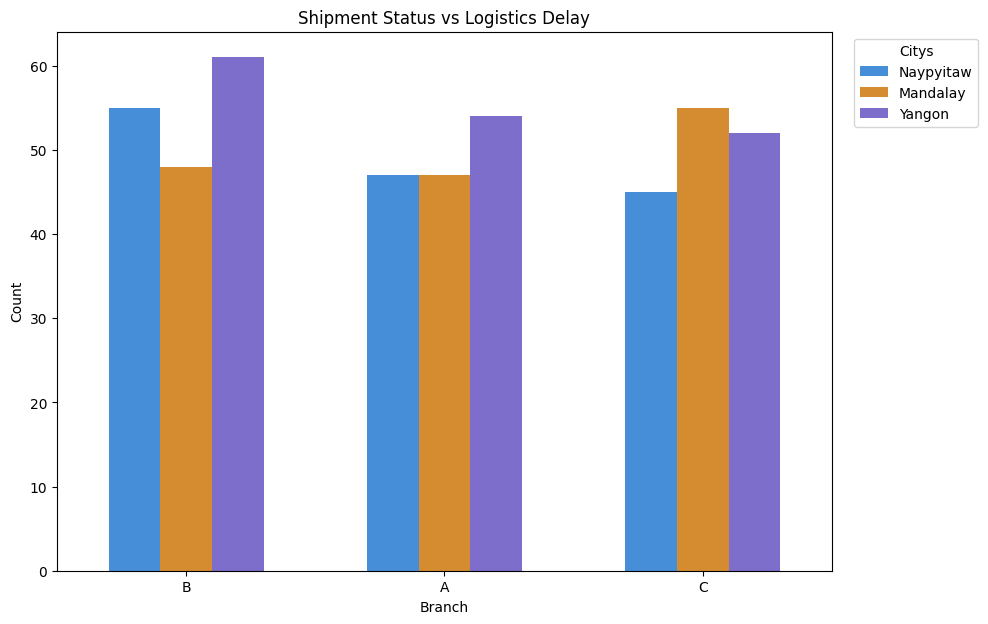

In [31]:
plt.figure(figsize=(10, 7))
sns.countplot(data=df, x='Branch', hue='City',palette=["#2F8DF0","#F08E15","#735EDB"],width=0.6)
plt.title('Shipment Status vs Logistics Delay')
plt.xlabel('Branch')
plt.ylabel('Count')
plt.legend(title='Citys',bbox_to_anchor=(1.02,1),loc='upper left')
plt.show()

### which branch has the overall highest rating?

In [32]:
df1=df.groupby('Branch')['Rating'].mean().round(2)
print(df1)

Branch
A    6.83
B    7.12
C    6.55
Name: Rating, dtype: float64


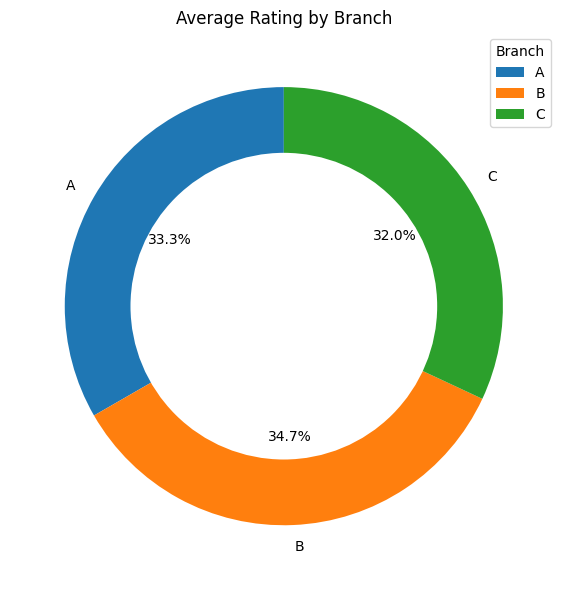

In [33]:
plt.figure(figsize=(6,6))

plt.pie(
    df1,
    labels=df1.index,
    autopct='%1.1f%%',
    startangle=90
)

# Donut effect
centre_circle = plt.Circle((0,0), 0.70, fc='white')
plt.gca().add_artist(centre_circle)

plt.title('Average Rating by Branch')
plt.tight_layout()
plt.legend(title='Branch')
plt.show()

Branch B has the highest rating

### How do average customer rating vary across branches within each city?

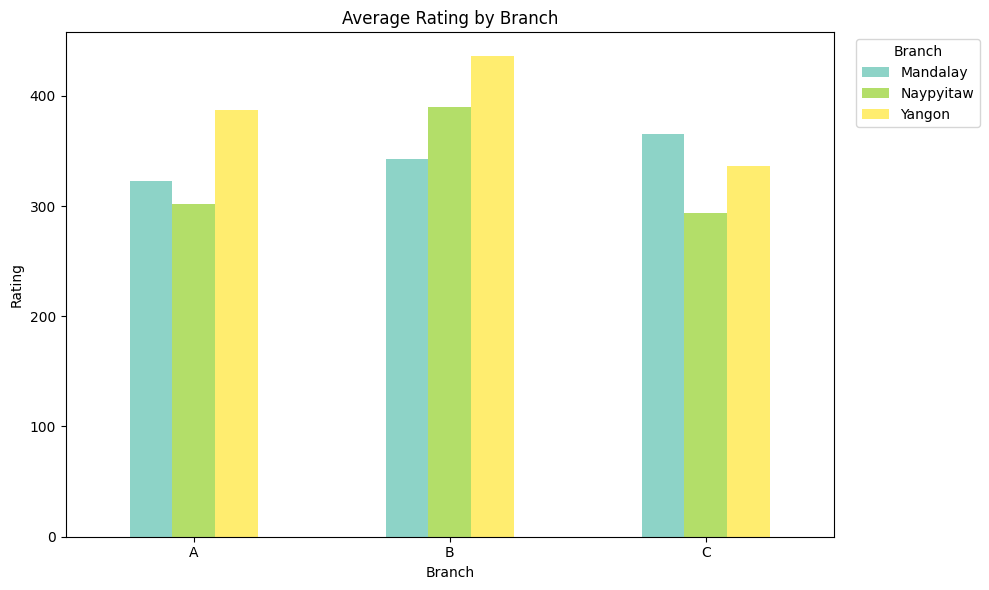

In [34]:
payment_summary = df.groupby(['Branch','City'])['Rating'].sum().unstack()

payment_summary.plot(kind='bar', figsize=(10,6), colormap='Set3')

plt.title('Average Rating by Branch')
plt.xlabel('Branch')
plt.ylabel('Rating')
plt.xticks(rotation=0)
plt.legend(title='Branch',bbox_to_anchor=(1.02,1),loc='upper left')
plt.tight_layout()
plt.show()

yangon city of branch A has the highest rating of all

### How many male and female customer are there

In [35]:
df['Gender'].value_counts()

Gender
Female    233
Male      231
Name: count, dtype: int64

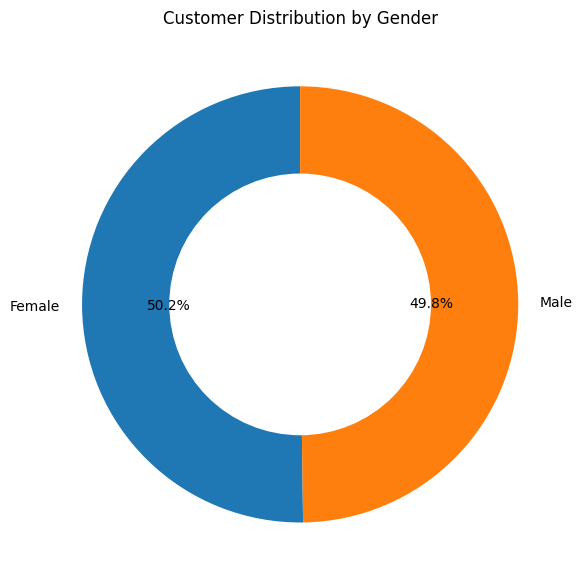

In [36]:
import matplotlib.pyplot as plt

# Count of customers by gender
gender_count = df['Gender'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender_count,
    labels=gender_count.index,
    autopct='%1.1f%%',
    startangle=90
)

# Donut hole
centre_circle = plt.Circle((0, 0), 0.6, fc='white')
plt.gca().add_artist(centre_circle)

plt.title('Customer Distribution by Gender')
plt.tight_layout()
plt.show()

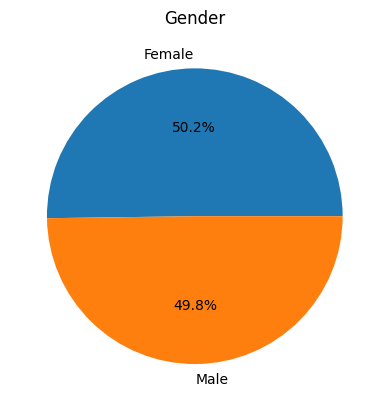

In [37]:
df['Gender'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title('Gender')
plt.ylabel('')
plt.show()

### who spend more member or normal customer

Customer_type
Member    124504.63
Normal    114462.84
Name: Total, dtype: float64


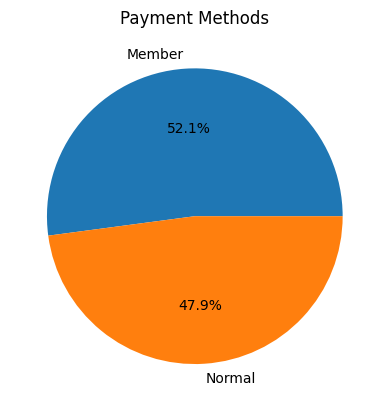

In [38]:
df1=df.groupby('Customer_type')['Total'].sum()
print(df1)
df1.plot(kind='pie',autopct='%1.1f%%')
plt.title('Payment Methods')
plt.ylabel('')
plt.show()


### Find and display the list of all unique products and the total number of different product types available.

In [39]:
df1=df['Product'].unique()
count=0
for i in df1:
    count=count+1
print(count)

30


In [40]:
df1=df['Product'].drop_duplicates(ignore_index=True)
print(df1)
print('Num of products :',df1.count())

0             Chair
1        Headphones
2        Power Bank
3          Sneakers
4           Charger
5              Soap
6             Scarf
7        Toothpaste
8              Belt
9           Handbag
10            Mouse
11              Tea
12            Juice
13       Sunglasses
14         Biscuits
15      Table Cover
16         Keyboard
17        Face Wash
18           Lotion
19    Travel Pillow
20     Water Bottle
21            Watch
22          Cushion
23          Curtain
24          Shampoo
25           Snacks
26             Tent
27           Coffee
28             Lamp
29         Backpack
Name: Product, dtype: object
Num of products : 30


### Which is the Top 3 sold product and less sold product?

In [75]:
top=df.groupby('Product')['Quantity'].sum().sort_values(ascending=False)
print('most sold',top.head(3))
print('less sold',top.tail(3))

most sold Product
Keyboard    149
Scarf       122
Soap        121
Name: Quantity, dtype: int64
less sold Product
Coffee         51
Table Cover    51
Backpack       49
Name: Quantity, dtype: int64


Keyboard is the most sold product, indicating high customer demand and strong market preference for this item Lamp is the least sold product, suggesting low customer interest or possible issues such as limited visibility, pricing, or product relevance.
This insight can help guide inventory decisions—increase stock and promotion for high-demand products like Keyboards, while re-evaluating marketing strategies, pricing, or product placement for Lamps to improve their sales.

### which age group make the highest number of purchases?

In [42]:
bins=[0,18,28,40,60,100]
labels=['1-18','19-28','29-40','41-60','61+']
df['age_group']=pd.cut(df['Customer_Age'],bins=bins,labels=labels,right=True)

sold=(df.groupby('age_group').size().reset_index(name="count"))
sold

C:\Users\abhij\AppData\Local\Temp\ipykernel_22060\2921316938.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sold=(df.groupby('age_group').size().reset_index(name="count"))


,age_group,count
0,1-18,11
1,19-28,97
2,29-40,111
3,41-60,201
4,61+,44


In [43]:
max=sold.loc[sold['count'].idxmax()]
max

age_group    41-60
count          201
Name: 3, dtype: object

C:\Users\abhij\AppData\Local\Temp\ipykernel_22060\2915442713.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sold,x='age_group',y='count',palette="hot")


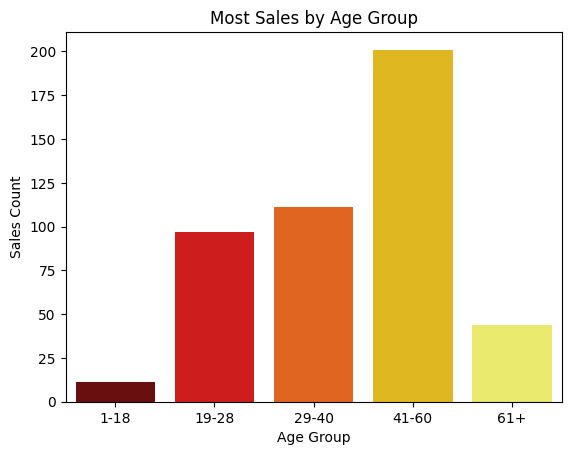

In [44]:

plt.bar(sold['age_group'],sold['count'])
sns.barplot(data=sold,x='age_group',y='count',palette="hot")
plt.xlabel('Age Group')
plt.ylabel('Sales Count')
plt.title('Most Sales by Age Group')
plt.show()

Around the age of 41-61 age category accounts for the highest number of customers and age of 1-18 has the lowest number of customers. so we need to Expand Appeal to Younger Customers,Engage Older Customers (61+),Evaluate Youth Segment (1–18)

### which is the most used payment method

In [45]:
df['Payment'].value_counts()

Payment
Cash           273
Ewallet        105
Credit card     86
Name: count, dtype: int64

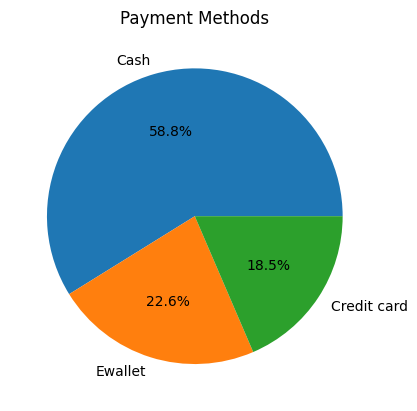

In [46]:
df['Payment'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title('Payment Methods')
plt.ylabel('')
plt.show()

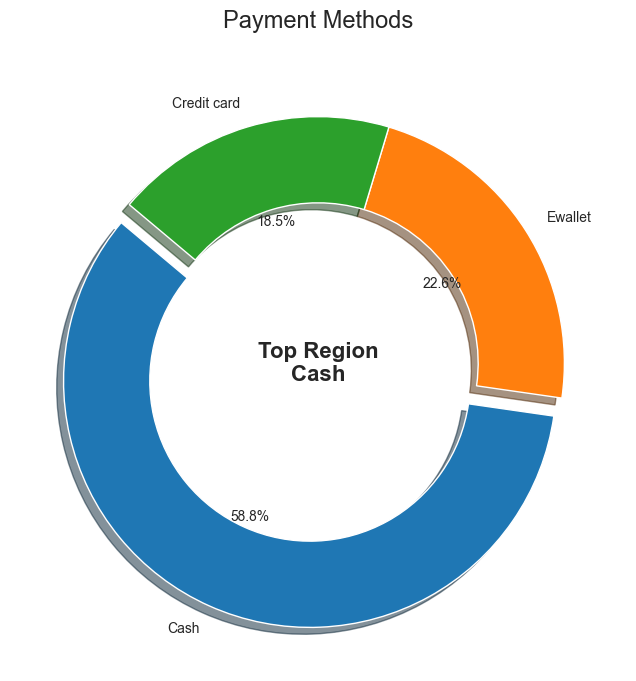

In [47]:
# Sales by region
region_sales = df['Payment'].value_counts()
top_region = region_sales.idxmax()

sns.set_style("white")

plt.figure(figsize=(8, 8))

# Highlight the highest region
explode = [0.08 if region == top_region else 0 for region in region_sales.index]

plt.pie(
    region_sales,
    labels=region_sales.index,
    autopct='%1.1f%%',
    startangle=140,
    explode=explode,
    wedgeprops=dict(width=0.35),
    shadow=True
)

# Center text
plt.text(
    0, 0,
    f"Top Region\n{top_region}",
    ha='center', va='center',
    fontsize=16, fontweight='bold'
)

plt.title("Payment Methods", fontsize=17, pad=20)
plt.show()

cash appears to be the most preferred payment method. This is mainly because the (41–60) age group has the highest number of customers, and this age group generally shows a stronger tendency to use cash compared to digital payment modes.

### Which payment method contributes the most to total sales in each product category?

In [48]:
payment_summary = df.groupby(['Category', 'Payment'])['Total'].sum().unstack()
payment_summary

Payment,Cash,Credit card,Ewallet
Category,,,
Electronic accessories,21560.21,9904.69,12460.21
Fashion accessories,26968.81,8054.86,4287.12
Food and beverages,21917.25,6723.31,6452.08
Health and beauty,27392.51,6958.63,12014.80
Home and lifestyle,22283.32,6311.77,6677.34
Sports and travel,23507.23,8113.62,7379.71


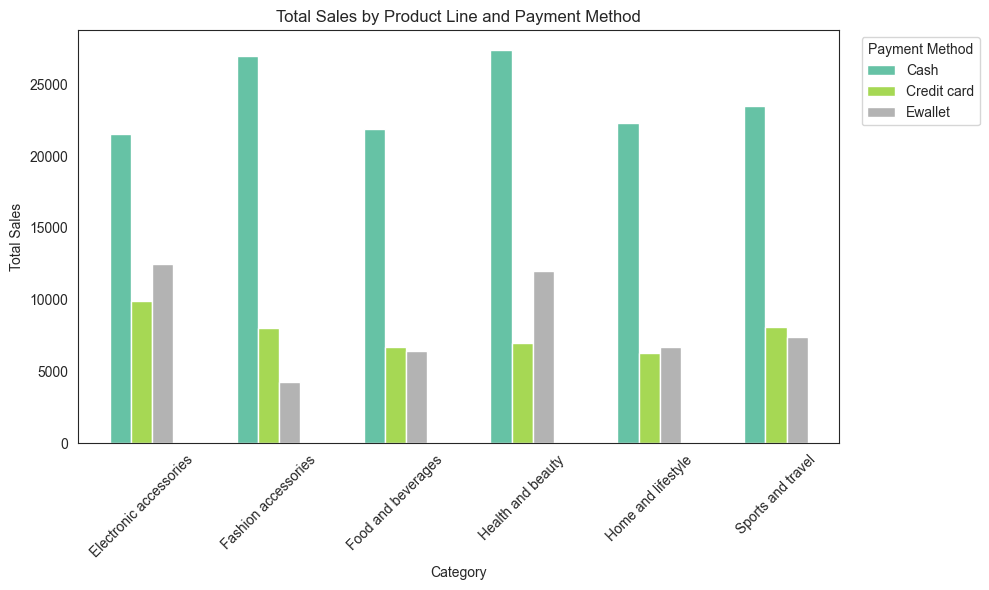

In [49]:
payment_summary = df.groupby(['Category', 'Payment'])['Total'].sum().unstack()

payment_summary.plot(kind='bar', figsize=(10,6), colormap='Set2')

plt.title('Total Sales by Product Line and Payment Method')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.legend(title='Payment Method',bbox_to_anchor=(1.02,1),loc='upper left')
plt.tight_layout()
plt.show()

Cash is the most preferred payment method across all product categories, contributing the highest total sales. E-wallets show moderate usage, while credit cards have the lowest contribution, indicating limited customer preference for card-based payments

### Calculate the total revenue (money earned) for each product ?

In [50]:
money=df.groupby('Product')['Total'].sum().sort_values(ascending=False)
print(money)
print('higest money earned by',money.head(1))
print('lowest money earned by',money.tail(1))


Product
Keyboard         12721.45
Soap             11454.83
Mouse            10952.85
Toothpaste       10871.27
Sneakers         10349.22
Scarf            10170.77
Face Wash         9767.67
Biscuits          9333.19
Shampoo           9182.00
Handbag           8932.11
Travel Pillow     8624.57
Tea               8566.75
Water Bottle      8449.03
Chair             8443.00
Curtain           8332.08
Headphones        7490.44
Juice             7389.50
Cushion           7376.14
Belt              7338.81
Power Bank        6718.70
Sunglasses        6629.85
Backpack          6381.23
Watch             6239.25
Charger           6041.67
Table Cover       5672.16
Coffee            5658.11
Lamp              5449.05
Tent              5196.51
Lotion            5090.17
Snacks            4145.09
Name: Total, dtype: float64
higest money earned by Product
Keyboard    12721.45
Name: Total, dtype: float64
lowest money earned by Product
Snacks    4145.09
Name: Total, dtype: float64


C:\Users\abhij\AppData\Local\Temp\ipykernel_22060\768790719.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Product', y='Total', palette="cool",errorbar=None,capsize=0)


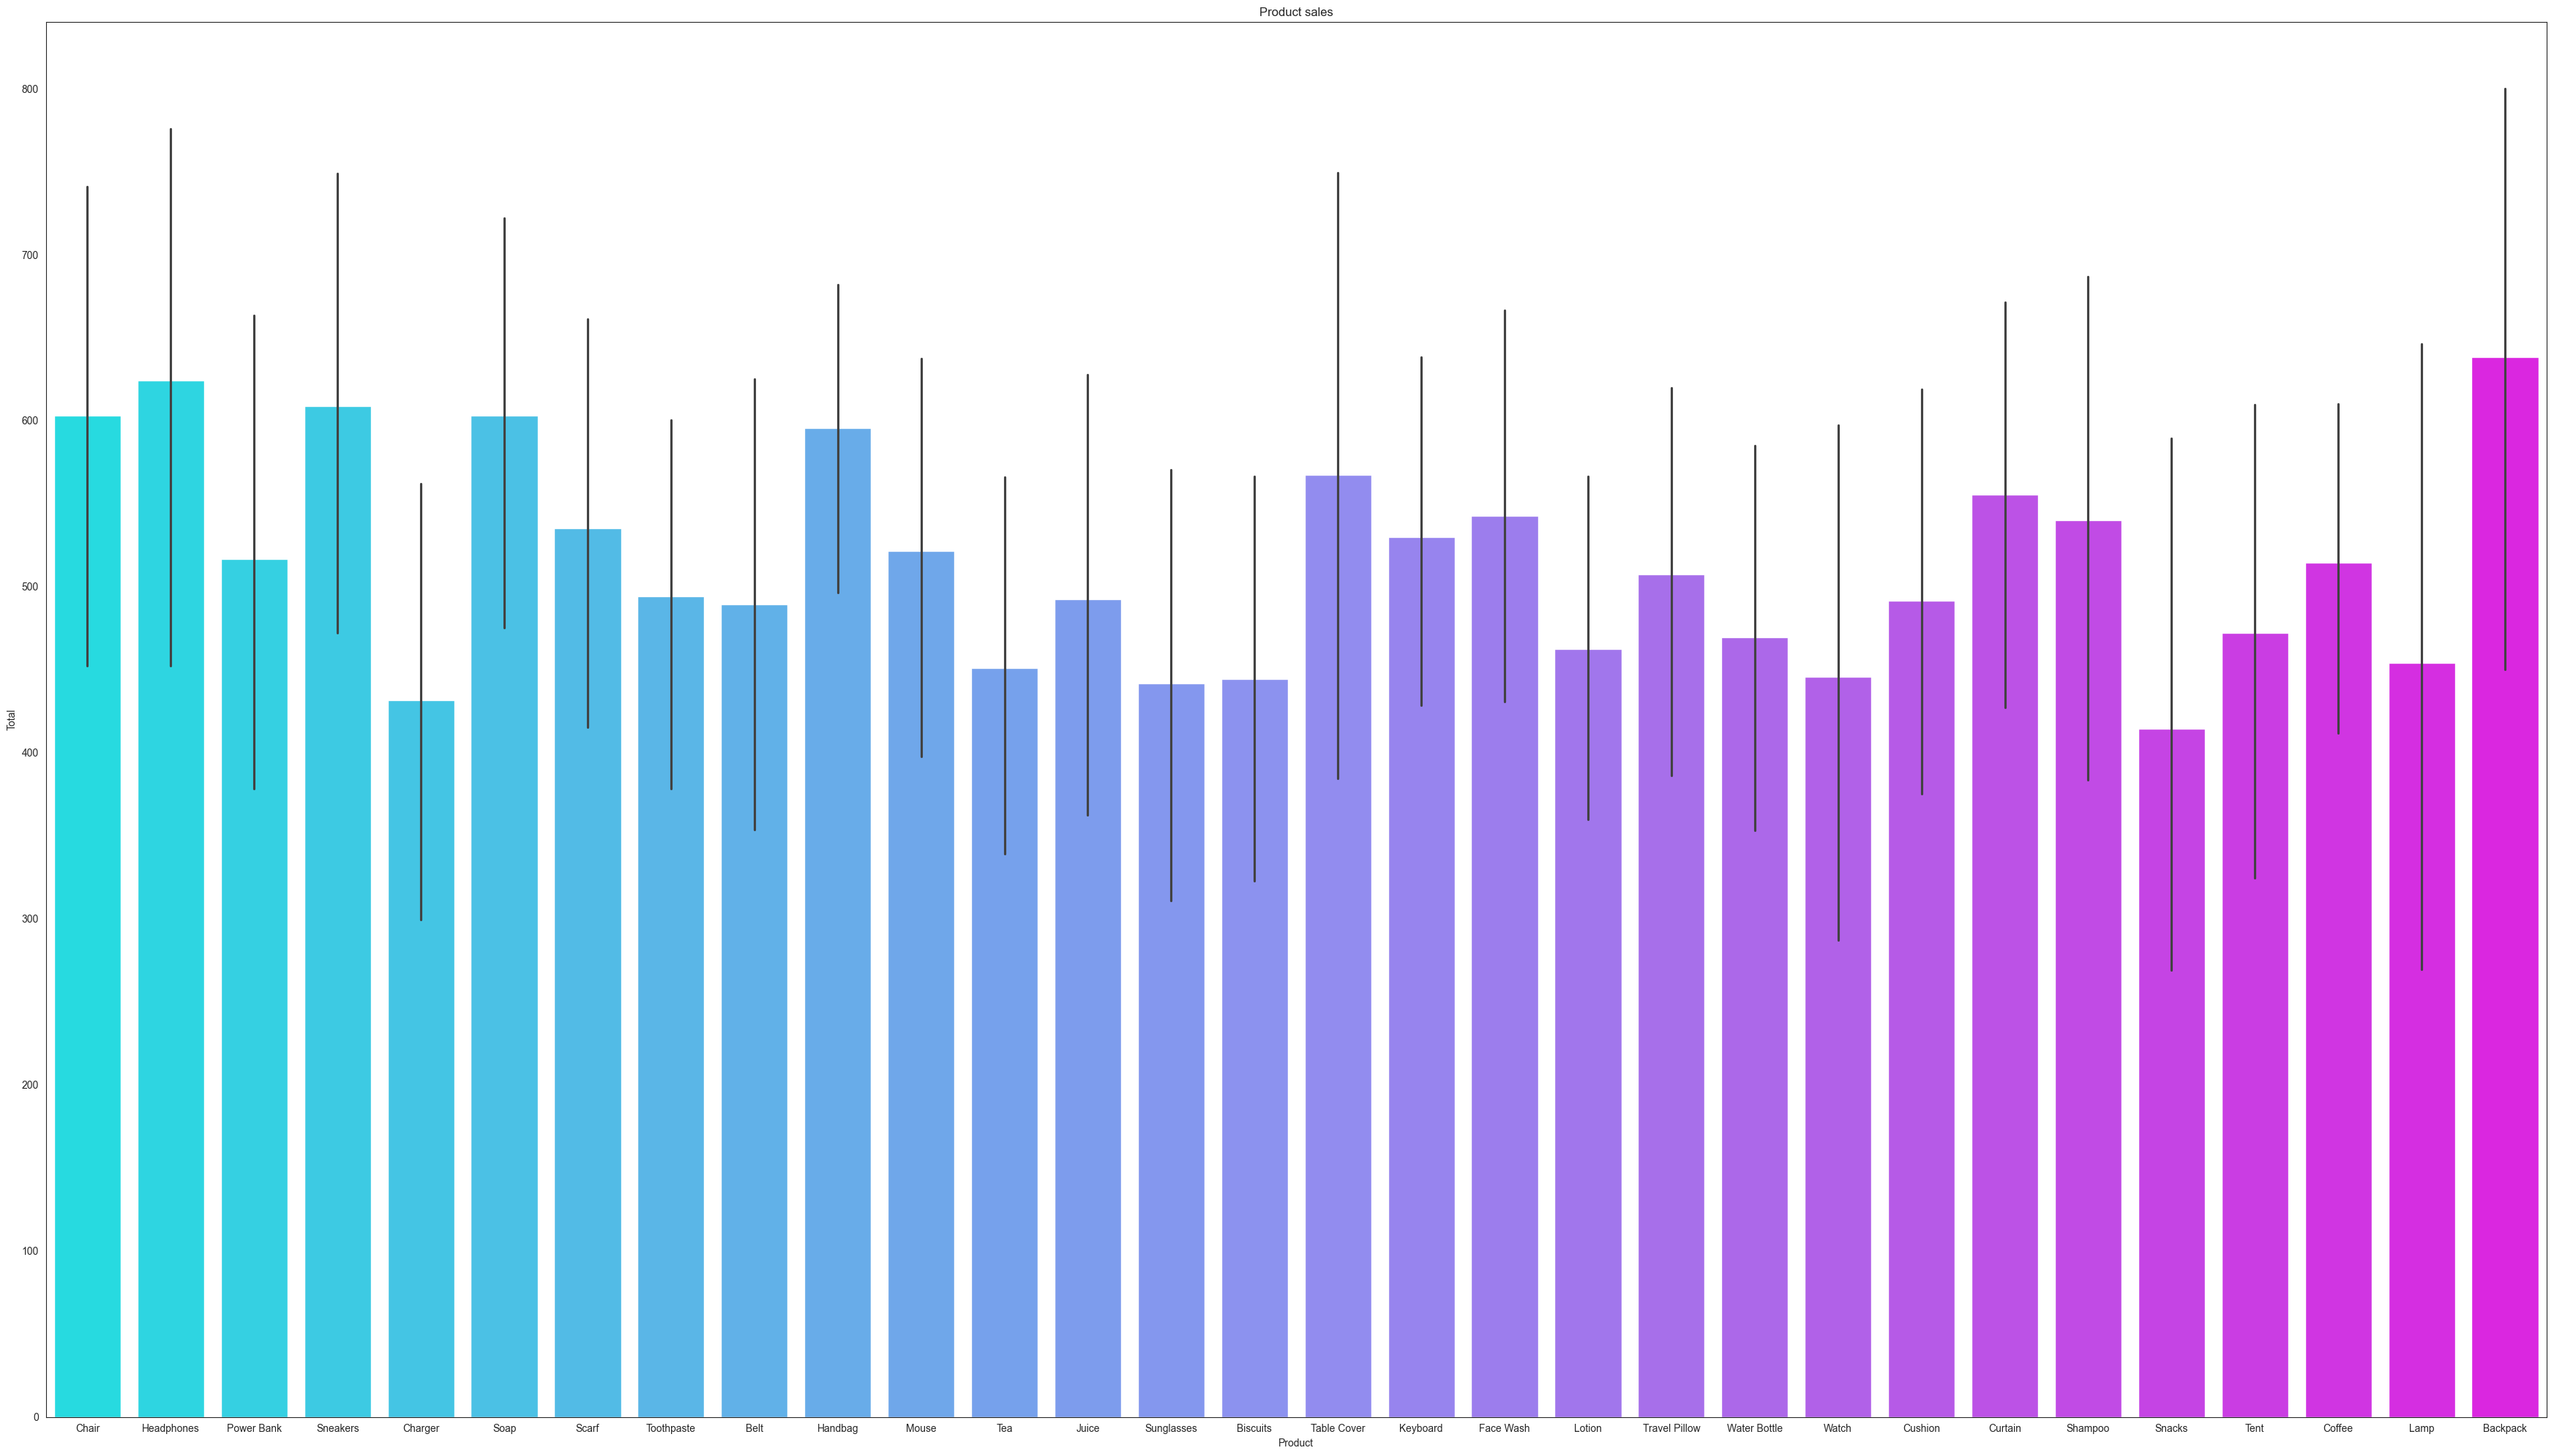

In [51]:
plt.figure(figsize=(35,20))
sns.barplot(x='Product', y='Total', data=df)
sns.barplot(data=df, x='Product', y='Total', palette="cool",errorbar=None,capsize=0)
plt.title('Product sales')
plt.tight_layout()
plt.show()


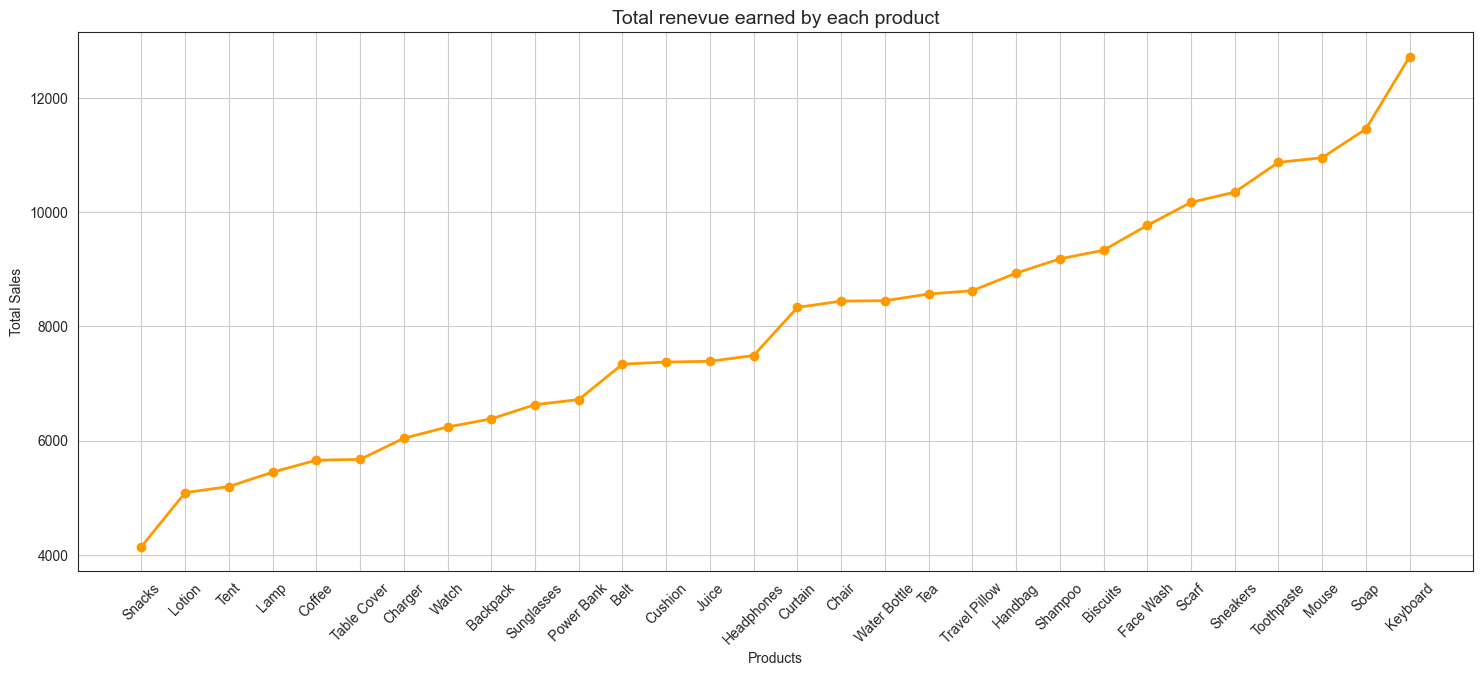

In [52]:
month = df.groupby(df['Product'])['Total'].sum().sort_values()
plt.figure(figsize=(18,7))
plt.plot(month.index, month.values, marker='o', linestyle='-', linewidth=2,color="#FF9900")
plt.title('Total renevue earned by each product', fontsize=14)
plt.xlabel('Products')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

The results show that Keyboard is the highest revenue-generating product, earning 12,721.45, indicating strong customer demand. Other products like Soap, Mouse, and Toothpaste also contribute significantly to total sales. In contrast, Snacks generate the lowest revenue (4,145.09), suggesting lower sales performance compared to other products. These insights help identify top-performing and underperforming products for better inventory and marketing decisions

### When did the highest sales occur?

In [53]:
df2=df.groupby(df['Time'].dt.hour)['Total'].sum().sort_values(ascending=False)
df2

Time
17    28913.64
13    23849.39
15    22775.99
20    22772.44
10    18556.20
18    18188.31
11    18033.69
9     17912.06
14    17870.08
16    17515.97
12    16504.35
19    16075.35
Name: Total, dtype: float64

In [54]:
df2=df2.reset_index()

C:\Users\abhij\AppData\Local\Temp\ipykernel_22060\43755858.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Time', y='Total',data=df2,palette="rainbow")


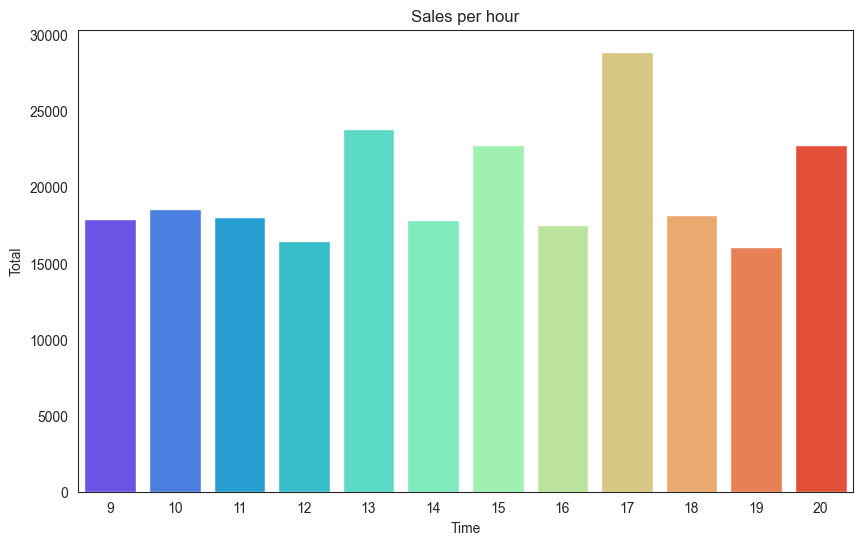

In [55]:
plt.figure(figsize=(10,6))
sns.barplot(x='Time', y='Total',data=df2,palette="rainbow")
plt.title('Sales per hour')
plt.show()

The analysis indicates that sales peak during the late afternoon and evening hours, with 5 PM (17:00) recording the highest total sales. Other high-performing time slots include 1 PM, 3 PM, and 8 PM, suggesting strong customer activity after midday. In contrast, late evening hours show comparatively lower sales, indicating reduced purchasing activity. These insights can help businesses optimize staffing, promotions, and inventory during peak sales hours.

### During which month has the highest transaction?

In [56]:
month=df.groupby(df['Date'].dt.month_name())['Total'].sum().sort_values(ascending=False)
month

Date
January      133467.85
September     17452.33
April         17016.46
February      15592.67
August        12146.46
May           12018.37
March         11015.20
July          10190.64
June          10067.49
Name: Total, dtype: float64

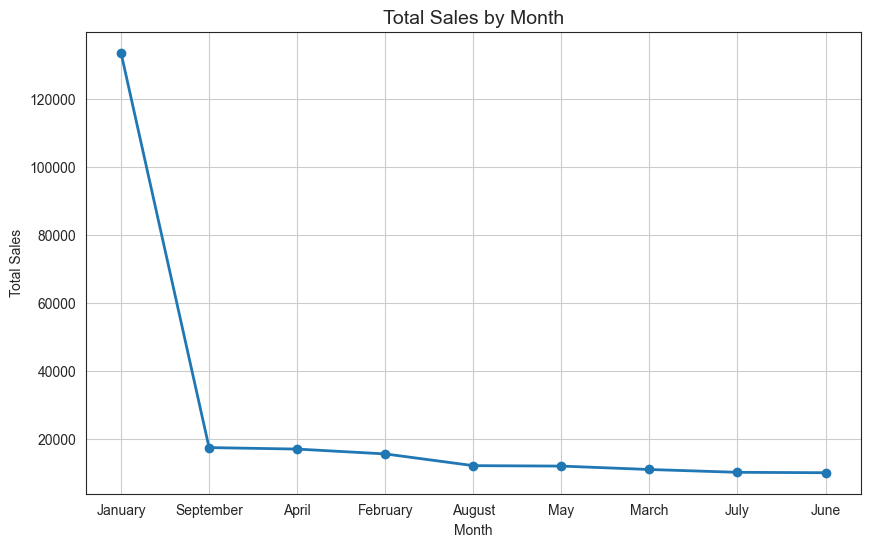

In [57]:

month = df.groupby(df['Date'].dt.month_name())['Total'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,6))
plt.plot(month.index, month.values, marker='o', linestyle='-', linewidth=2)
plt.title('Total Sales by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

The analysis shows that January records the highest total revenue, significantly outperforming all other months, indicating a strong peak in sales at the beginning of the year. September and April follow with moderate sales, while June and July show the lowest revenue, suggesting reduced customer activity during these months. This pattern highlights seasonal trends that can guide inventory planning, staffing, and promotional strategies

### During which day has the highest transaction?

In [58]:
df3=df.groupby(df['Date'].dt.day_name())['Total'].sum().sort_values(ascending=False)


In [59]:
df3

Date
Friday       57245.32
Tuesday      40167.10
Saturday     37058.37
Monday       31677.47
Thursday     28570.08
Sunday       25239.86
Wednesday    19009.27
Name: Total, dtype: float64

In [60]:
df3=df3.reset_index()

C:\Users\abhij\AppData\Local\Temp\ipykernel_22060\3989841911.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Date', y='Total',data=df3,palette="rainbow")


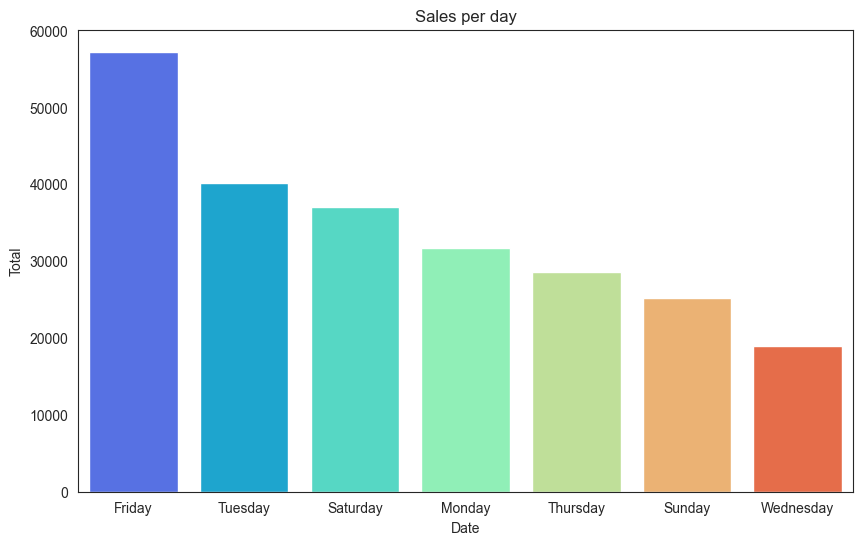

In [61]:
df1=df.groupby(df['Date'].dt.day_name())['Total'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x='Date', y='Total',data=df3,palette="rainbow")
plt.title('Sales per day')
plt.show()

The day-wise sales analysis shows that Friday generates the highest total revenue, indicating peak customer activity at the end of the workweek. Tuesday and Saturday also perform strongly, while Wednesday records the lowest sales, suggesting reduced midweek purchasing. These insights can help optimize staffing, promotions, and sales campaigns by focusing on high-performing days.

### Which product has the highest average sales?

In [62]:
avg=df.groupby('Product')['Total'].mean().sort_values()

print(avg)
print('Highest avg sales has',avg.tail(1))
print('Lowest avg sales has',avg.head(1))

Product
Snacks           414.509000
Charger          431.547857
Sunglasses       441.990000
Biscuits         444.437619
Watch            445.660714
Tea              450.881579
Lamp             454.087500
Lotion           462.742727
Water Bottle     469.390556
Tent             472.410000
Belt             489.254000
Cushion          491.742667
Juice            492.633333
Toothpaste       494.148636
Travel Pillow    507.327647
Coffee           514.373636
Power Bank       516.823077
Mouse            521.564286
Keyboard         530.060417
Scarf            535.303684
Shampoo          540.117647
Face Wash        542.648333
Curtain          555.472000
Table Cover      567.216000
Handbag          595.474000
Soap             602.885789
Chair            603.071429
Sneakers         608.777647
Headphones       624.203333
Backpack         638.123000
Name: Total, dtype: float64
Highest avg sales has Product
Backpack    638.123
Name: Total, dtype: float64
Lowest avg sales has Product
Snacks    414.509

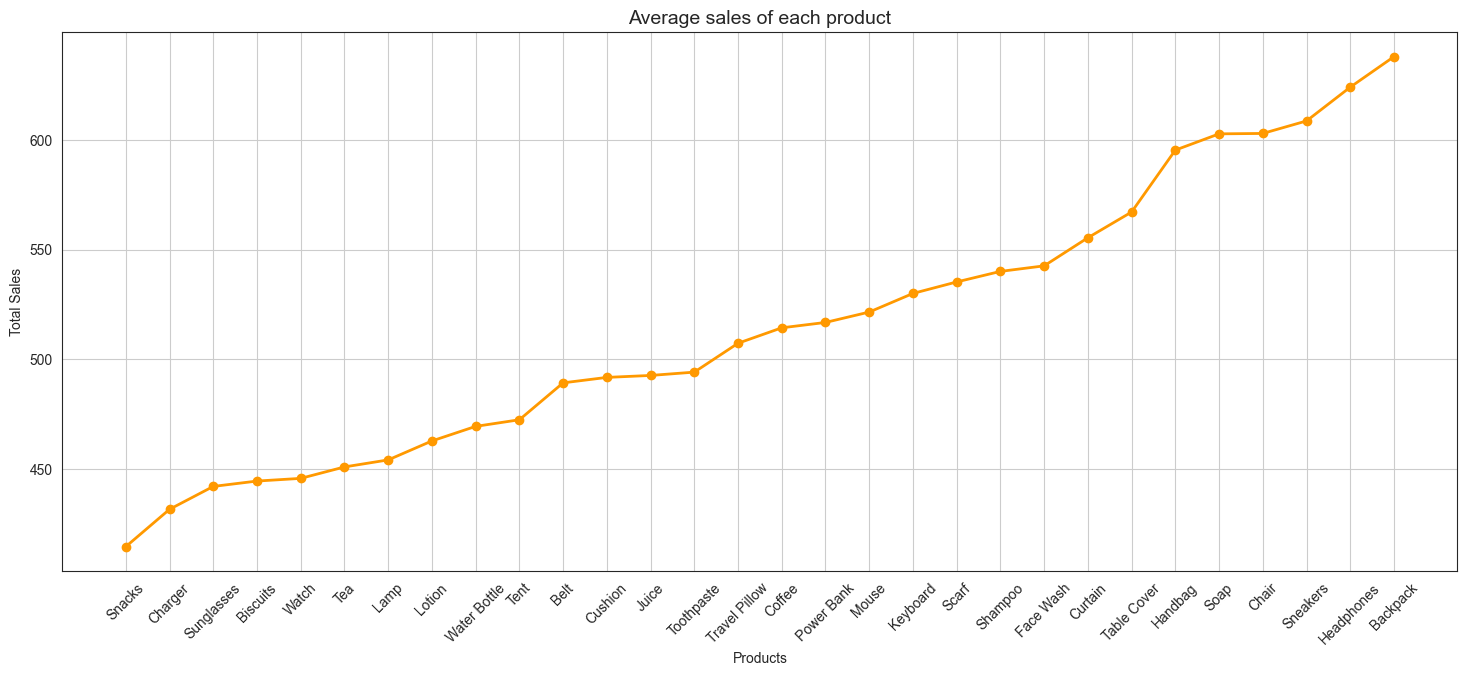

In [63]:
month = df.groupby(df['Product'])['Total'].mean().sort_values()
plt.figure(figsize=(18,7))
plt.plot(month.index, month.values, marker='o', linestyle='-', linewidth=2,color="#FF9900")
plt.title('Average sales of each product', fontsize=14)
plt.xlabel('Products')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

Highest average sales has Backpack and lowest average sales has Snacks

### Which product belong to each category? 

In [64]:
df3=df.groupby('Category')['Product']

In [65]:
df3.value_counts()

Category                Product      
Electronic accessories  Keyboard         24
                        Mouse            21
                        Charger          14
                        Power Bank       13
                        Headphones       12
Fashion accessories     Scarf            19
                        Belt             15
                        Handbag          15
                        Sunglasses       15
                        Watch            14
Food and beverages      Biscuits         21
                        Tea              19
                        Juice            15
                        Coffee           11
                        Snacks           10
Health and beauty       Toothpaste       22
                        Soap             19
                        Face Wash        18
                        Shampoo          17
                        Lotion           11
Home and lifestyle      Curtain          15
                        Cushion       

### How much income dose each category makes

In [66]:
df.groupby('Category')['Total'].sum().sort_values(ascending=False)

Category
Health and beauty         46365.94
Electronic accessories    43925.11
Fashion accessories       39310.79
Sports and travel         39000.56
Home and lifestyle        35272.43
Food and beverages        35092.64
Name: Total, dtype: float64

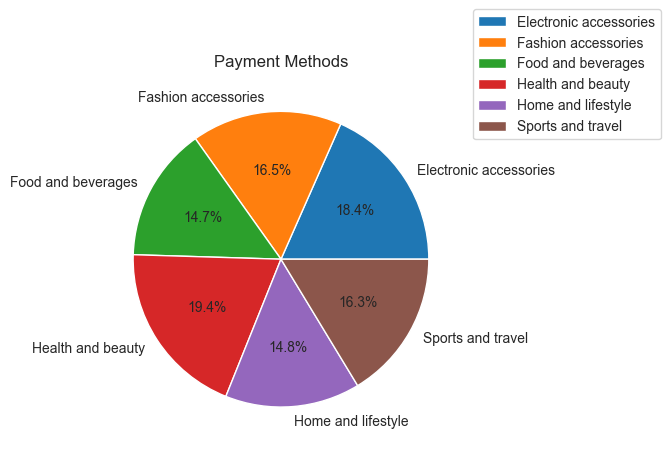

In [67]:
df1=df.groupby('Category')['Total'].sum()

df1.plot(kind='pie',autopct='%1.1f%%')
plt.title('Payment Methods')
plt.ylabel('')
plt.legend(loc='center left', bbox_to_anchor=(1,1))
plt.show()

The category-wise analysis shows that Health and Beauty generates the highest total revenue, followed by Electronic Accessories and Fashion Accessories, indicating strong customer demand in these categories. In contrast, Food and Beverages records the lowest revenue among the categories. These insights help businesses prioritize high-performing categories and improve strategies for lower-performing ones.

### How dose customer feedback vary acrooss different branches?

In [68]:
df1=df.groupby('Branch')['Feedback']

In [69]:
df1.value_counts()

Branch  Feedback 
A       Good         57
        Excellent    46
        very good    25
        Poor         20
B       Excellent    61
        Good         48
        very good    34
        Poor         21
C       Excellent    59
        Good         48
        Poor         24
        very good    21
Name: count, dtype: int64

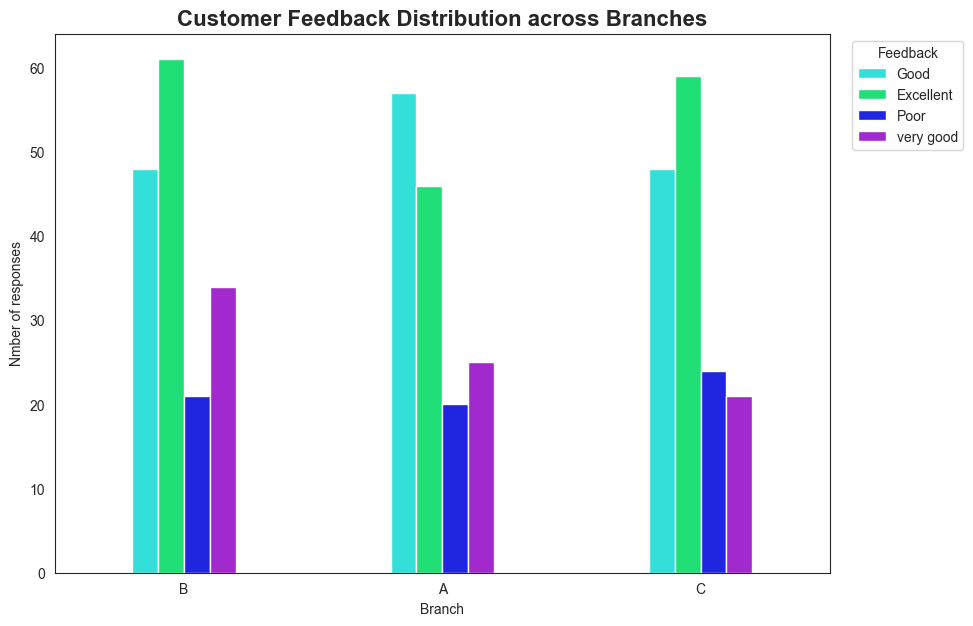

In [70]:
plt.figure(figsize=(10, 7))
sns.countplot(data=df, x='Branch', hue='Feedback',palette=["#15fcf4","#00ff73","#0008ff","#ae0ee8ff"],width=0.4)
plt.title('Customer Feedback Distribution across Branches',fontsize=16,fontweight='bold')
plt.xlabel('Branch')
plt.ylabel('Nmber of responses')
plt.legend(title='Feedback',bbox_to_anchor=(1.02,1),loc='upper left')
plt.show()

Almost all branches has good feedbacks

### which product are prefred by each gender? 

In [71]:
df1=df.groupby('Gender')['Product']

In [72]:
df1.value_counts()

Gender  Product      
Female  Toothpaste       13
        Cushion          12
        Keyboard         12
        Shampoo          11
        Soap             10
        Biscuits          9
        Chair             9
        Charger           9
        Handbag           9
        Tea               9
        Travel Pillow     9
        Water Bottle      9
        Belt              8
        Mouse             8
        Scarf             8
        Sunglasses        8
        Watch             8
        Power Bank        7
        Snacks            7
        Backpack          6
        Curtain           6
        Face Wash         6
        Sneakers          6
        Table Cover       6
        Headphones        5
        Juice             5
        Lamp              5
        Lotion            5
        Coffee            4
        Tent              4
Male    Mouse            13
        Biscuits         12
        Face Wash        12
        Keyboard         12
        Scarf            1

### which category are prefred by each gender? 

In [73]:
df1=df.groupby('Gender')['Category']

In [74]:
df1.value_counts()

Gender  Category              
Female  Health and beauty         45
        Electronic accessories    41
        Fashion accessories       41
        Home and lifestyle        38
        Food and beverages        34
        Sports and travel         34
Male    Electronic accessories    43
        Food and beverages        42
        Health and beauty         42
        Sports and travel         39
        Fashion accessories       37
        Home and lifestyle        28
Name: count, dtype: int64

female prefer health and beauty and Home and lifestyle ,male prefer Sports and travel and Electronic accessories most

# Final Conclusion

This project presented a comprehensive exploratory data analysis of supermarket sales data using Python’s Pandas library, supported by NumPy, Matplotlib, and Seaborn for statistical computation and visualization. Through systematic data preprocessing, including handling missing values, correcting inconsistencies, and transforming variables, the dataset was prepared for meaningful analysis.

The results demonstrate that Branch B records the highest overall average customer rating, while Branch A in Yangon city achieves the highest branch–city-specific rating, reflecting strong customer satisfaction in these locations. Gender analysis indicates a fairly balanced customer base; however, purchasing behavior differs notably across genders. Female customers show a stronger preference for Health & Beauty and Home & Lifestyle categories, whereas male customers predominantly favor Sports & Travel and Electronic Accessories.

Product-level analysis highlights Keyboards as the most sold product in terms of quantity, confirming high demand, while Lamps and Snacks exhibit comparatively low sales performance. Revenue analysis reveals that Keyboards generate the highest total revenue, whereas Snacks contribute the least, indicating disparities between sales volume and revenue contribution. Additionally, Backpacks record the highest average sales value, while Snacks again rank lowest, emphasizing product-level pricing and demand differences.

Customer demographic analysis shows that the 41–60 age group accounts for the highest number of purchases, establishing this segment as the primary revenue driver. This dominance also influences transaction behavior, as cash emerges as the most preferred payment method across all categories, particularly among middle-aged customers. Temporal analysis identifies late afternoon and evening hours (especially 5 PM) as peak sales periods, with January being the highest revenue-generating month and Friday the most profitable day, reflecting clear seasonal and weekly purchasing patterns.

Category-wise evaluation reveals that Health & Beauty generates the highest overall revenue, followed by Electronic Accessories and Fashion Accessories, while Food & Beverages contributes the least. Feedback analysis further indicates that most branches receive predominantly positive customer feedback, suggesting satisfactory service quality across locations.

Overall, the project successfully demonstrates how structured data analysis using Pandas can transform raw transactional data into actionable business insights related to customer behavior, sales performance, and operational efficiency.

# Suggestions and Recommendations

Leverage high-performing branches (Branch B and Branch A – Yangon) by adopting their service practices across other branches to improve customer satisfaction uniformly.

Focus marketing strategies on the 41–60 age group, as they represent the largest and most valuable customer segment.

Improve low-performing products such as Snacks and Lamps by revising pricing, enhancing promotions, or improving product placement.

Increase stock and promotion for high-demand products like Keyboards and Backpacks to maximize revenue and customer satisfaction.

Encourage digital payment adoption through discounts or loyalty incentives to reduce heavy dependence on cash transactions.

Implement gender-specific marketing campaigns based on category preferences to improve engagement and sales conversion.

Optimize staffing, inventory, and promotional activities during peak hours (late afternoon/evening), peak days (Friday), and peak months (January).

Extend future work by incorporating predictive analytics, customer segmentation models, and sentiment analysis on feedback data to enhance decision-making accuracy.